Online Retail Data Analysis

Objective:
Analyze sales data to find insights about revenue, customers, and trends.

Dataset Description:
- InvoiceNo
- StockCode
- Description
- Quantity
- InvoiceDate
- UnitPrice
- CustomerID
- Country

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
pd.set_option('future.no_silent_downcasting', True)
df=pd.read_excel('Online Retail.xlsx')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Data Cleaning

- Removed missing CustomerID
- Removed negative Quantity and UnitPrice
- Filled missing values

In [8]:
df.duplicated().sum()

np.int64(5268)

In [9]:
df=df.drop_duplicates()
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [10]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [11]:
df=df.dropna(subset=['CustomerID'])
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [12]:
df=df.fillna('NA').infer_objects(copy=False)
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [13]:
df=df[df['UnitPrice']>0]
df=df[df['Quantity']>0]
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [14]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['Year']=df['InvoiceDate'].dt.year
df['Month']=df['InvoiceDate'].dt.month
df['Day']=df['InvoiceDate'].dt.day 
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011,12,9
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12,9
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9


SECTION A :Sales Analysis

In [15]:
# Q1 total revenue 
total_revenue=df['TotalPrice'].sum()
total_revenue

np.float64(8887208.894000001)

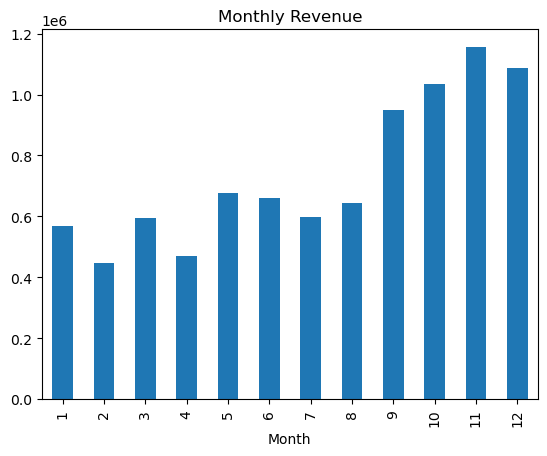

In [16]:
# Q2 Revenue by month 
monthly_sales=df.groupby('Month')['TotalPrice'].sum()
monthly_sales
monthly_sales.plot(kind='bar')
plt.title('Monthly Revenue')
plt.show()

# MONTHLY REVENUE INSIGHTS
KEY FINDINGS:
• November & December = BIG MONEY months
• February = Slowest month (people broke after holidays )
• Sales grow all year until holiday rush

WHAT THIS MEANS:
Stock up before November! Don't run out of popular items.
Plan for slow February - maybe run special promotions?

In [17]:
# Q3: Top Selling Products
top_products=df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

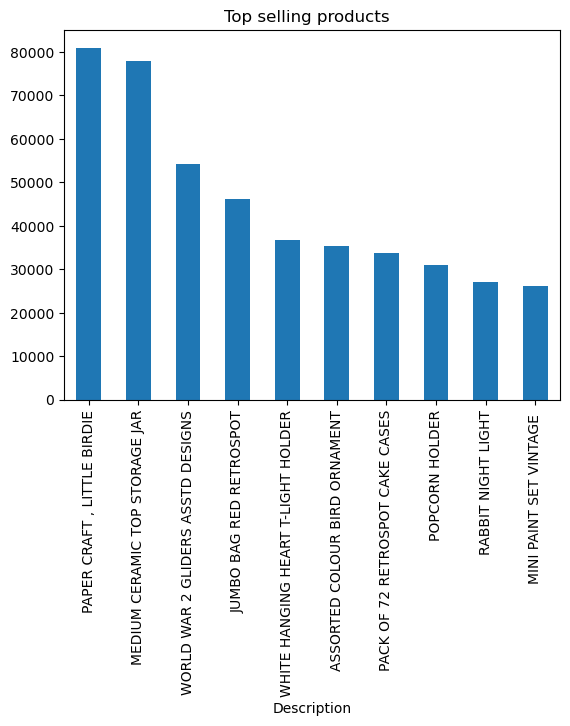

In [ ]:
top_products.plot(kind='bar')
plt.title('Top selling products  ')
plt.show()

# TOP PRODUCTS INSIGHTS
"""
KEY FINDINGS:
• PAPER CRAFT BIRDIE = #1 seller (80k+ units!)
• Storage jars and gliders are super popular
• All top items are relatively cheap (under $10)

WHAT THIS MEANS:
People LOVE affordable, practical items!
These should always be in stock.
Maybe bundle these with expensive items to increase sales?
"""

In [19]:
# Q4: What is the total number of Product sale 
total_sale=df['Quantity'].sum()
total_sale

np.int64(5152002)

In [20]:
# Q5 :What is the average price of products 
avg_price=df['UnitPrice'].mean()
avg_price

np.float64(3.1259139070823956)

In [21]:
# Q6: What is the total number of transactions
transaction=df['InvoiceNo'].nunique()
transaction

18532

In [22]:
# Q7: What is the maximum order value 
order_value=df.groupby('InvoiceNo')['TotalPrice'].sum()
max_order=order_value.max()
max_order

168469.6

In [23]:
# Q8: What is the minimum order value 
min_order=order_value.min()
min_order

0.38

SECTION B : Visulaization

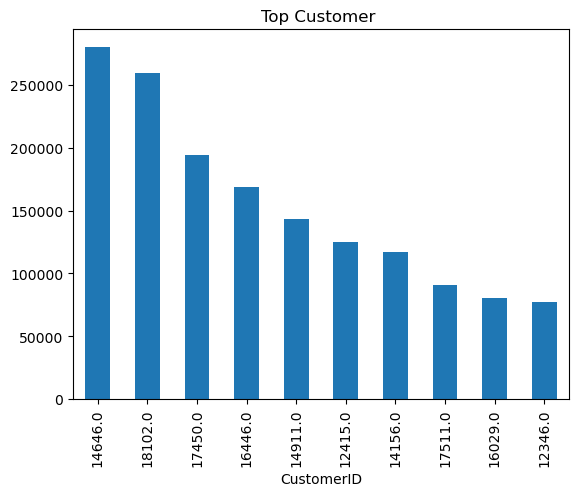

In [ ]:
top_customer.plot(kind='bar')
plt.title('Top Customer ')
plt.show()

# TOP CUSTOMERS INSIGHTS
"""
 KEY FINDINGS:
• Few customers spend A LOT of money
• Most customers spend smaller amounts
• Top 10 customers probably bring in most revenue

 WHAT THIS MEANS:
Take REALLY good care of your big spenders! 
Give them special deals, early access, etc.
But don't forget regular customers - they add up!
"""

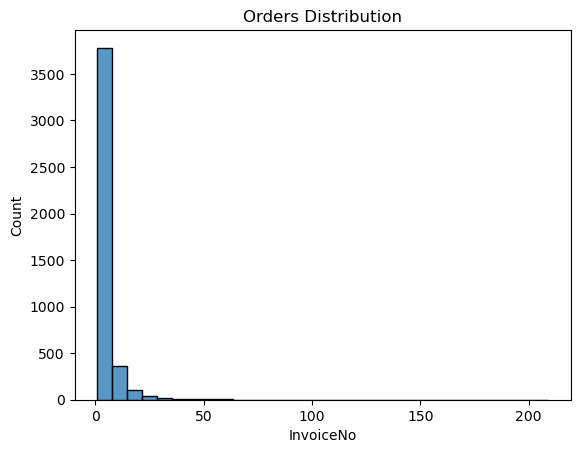

In [ ]:
sns.histplot(orders,bins=30)
plt.title('Orders Distribution')
plt.show()

#  CUSTOMER ORDER PATTERNS
"""
 KEY FINDINGS:
• Most people buy 1-5 times only
• Very few people buy lots of times
• Shape looks like a slide (big drop off)

 WHAT THIS MEANS:
Getting new customers is important!
But keeping existing customers is GOLD 
Maybe create loyalty programs to bring people back?
"""

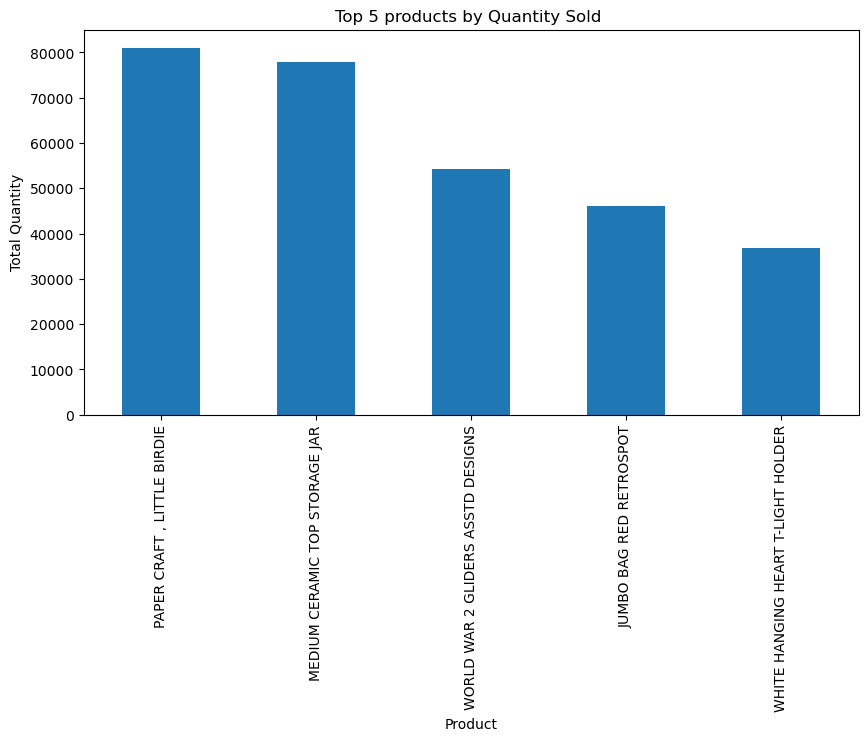

In [26]:
# Q11: Bar charts of top 5 Products by quantity
top_products=df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title('Top 5 products by Quantity Sold ')
plt.xlabel('Product')
plt.ylabel('Total Quantity')
plt.show()

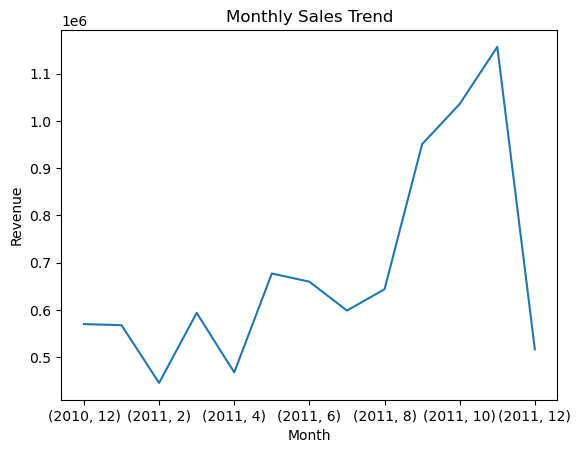

In [27]:
# Q12: line chart of monthly sale
monthly_sales = df.groupby(['Year','Month'])['TotalPrice'].sum()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


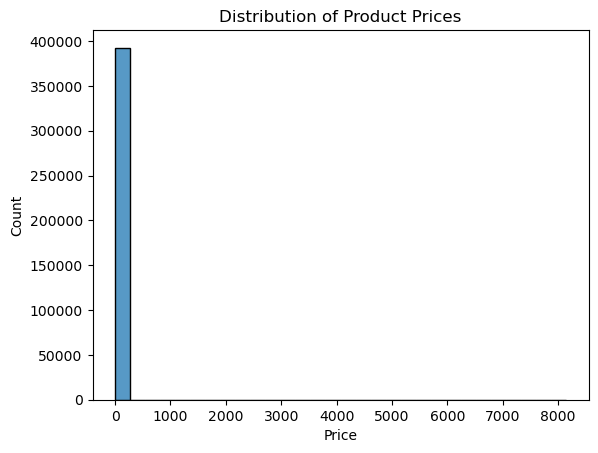

In [ ]:
sns.histplot(df['UnitPrice'],bins=30)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# 💰 PRODUCT PRICE INSIGHTS
"""
 KEY FINDINGS:
• Most products are CHEAP (under $10)
• Very few expensive products (some cost thousands!)
• Lots of products around $1-5 range

 WHAT THIS MEANS:
This is a discount/affordable store! 
People come here for bargains, not luxury items
Should focus on volume sales, not high margins
"""

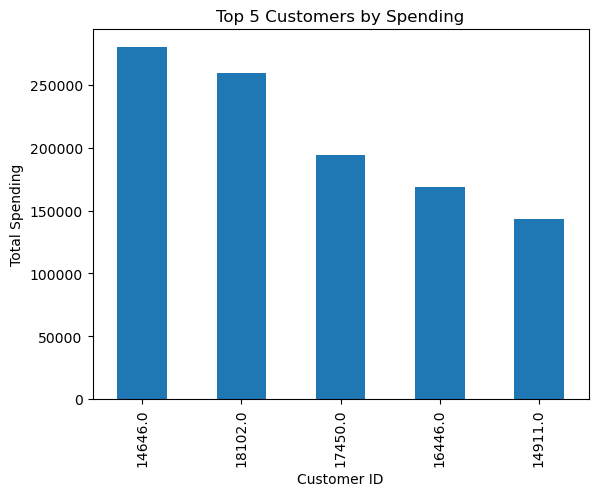

In [29]:
# Q14: Bar chart of top 5 customers 
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(5)
top_customers.plot(kind='bar')
plt.title("Top 5 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.show()

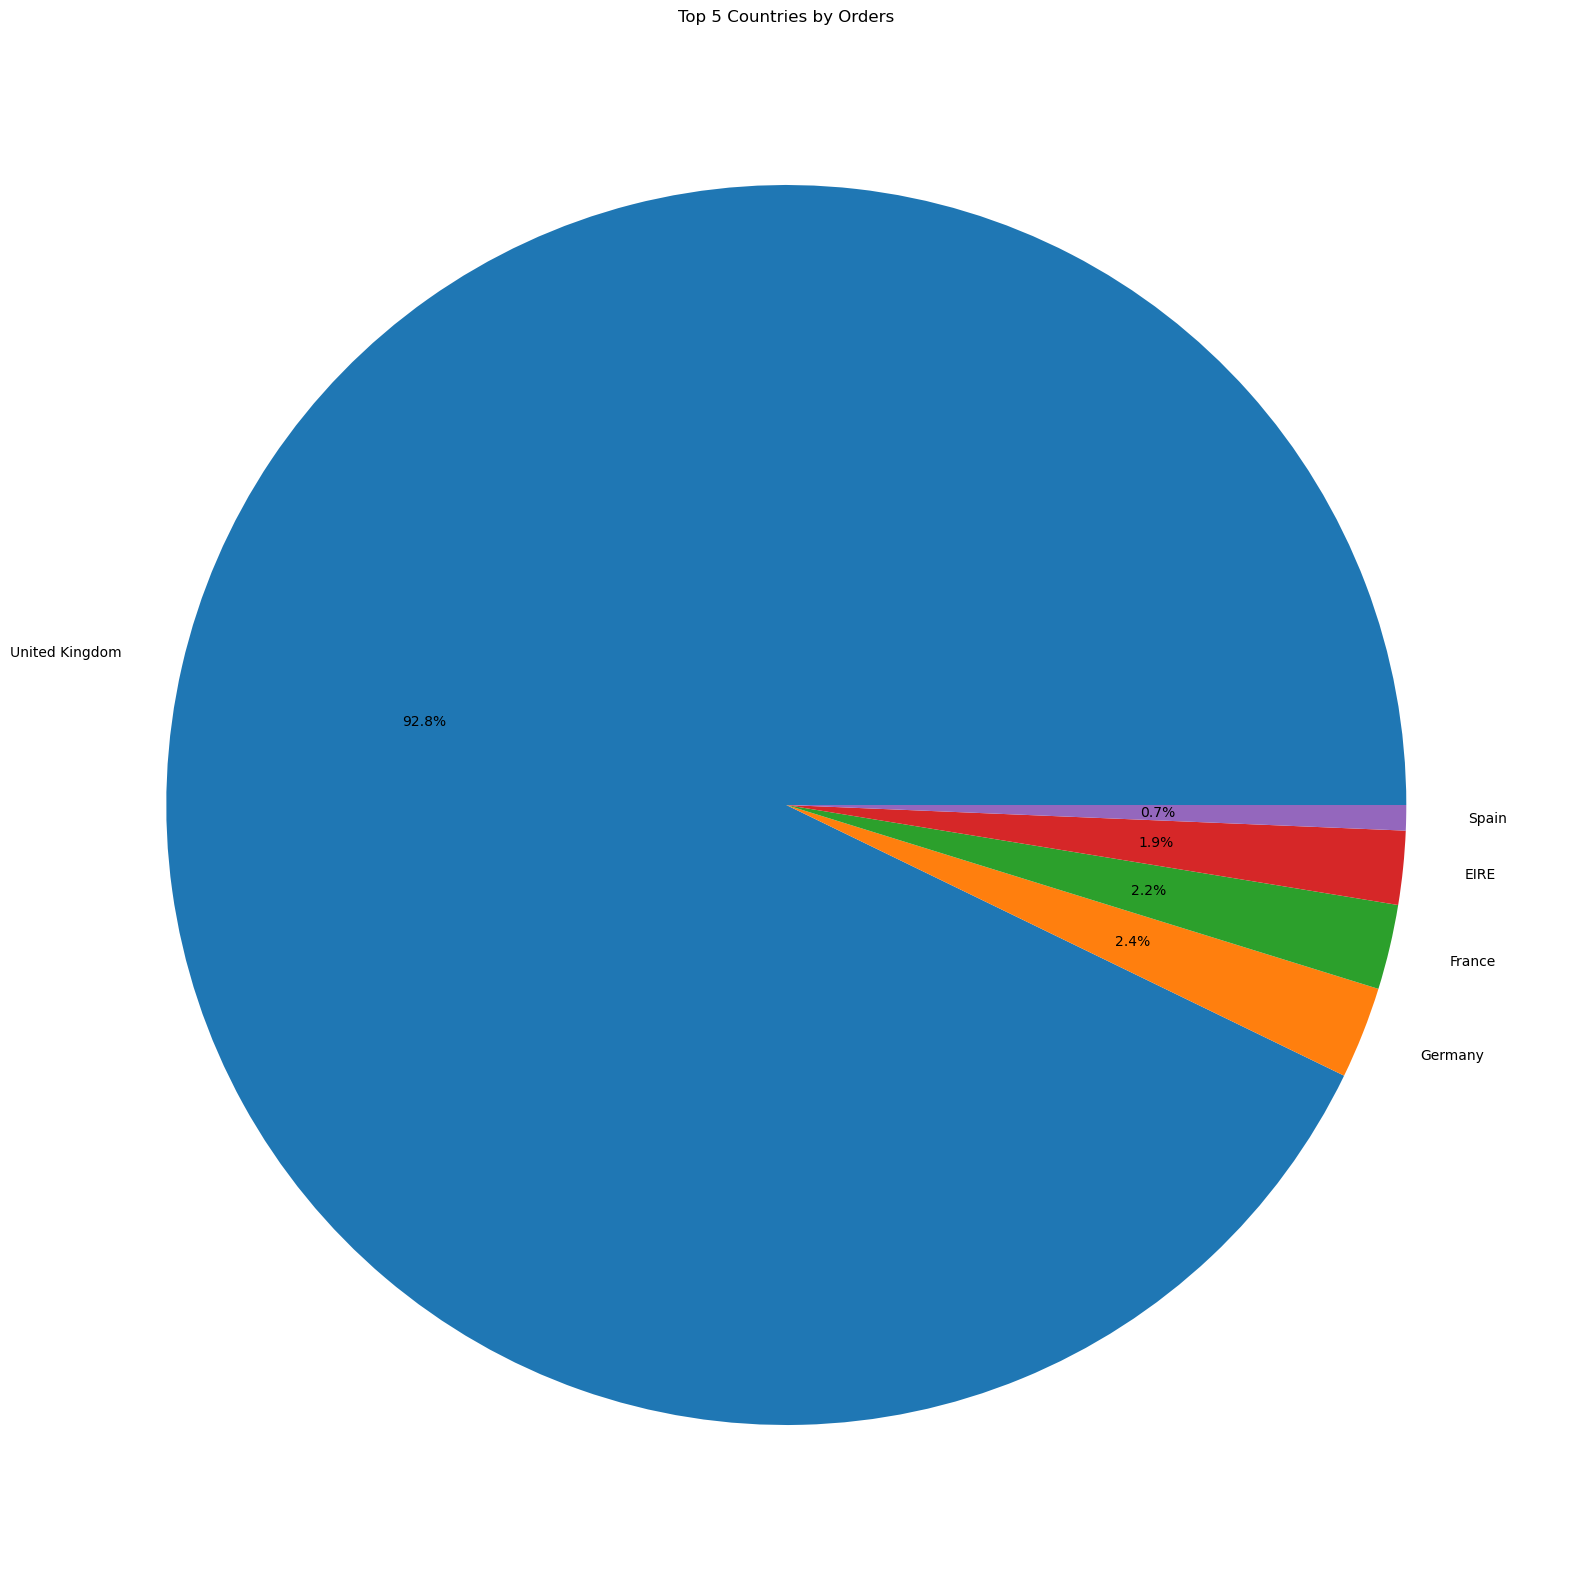

In [ ]:
top_country = df['Country'].value_counts().head(5)
plt.figure(figsize=(20,50))
top_country.plot(kind='pie', autopct='%1.1f%%')
plt.title("Top 5 Countries by Orders")
plt.ylabel("")
plt.show()

#  COUNTRY BREAKDOWN INSIGHTS
"""
 KEY FINDINGS:
• UK is KING! 🇬🇧 (90%+ of all orders!)
• Germany & France are distant #2 & #3
• Very international (37 countries total!)

 WHAT THIS MEANS:
UK is your home turf - protect it! 
But don't ignore other countries - they add up
Maybe translate website for German/French customers?
"""

SECTION C: COUNTRY ANALYSIS

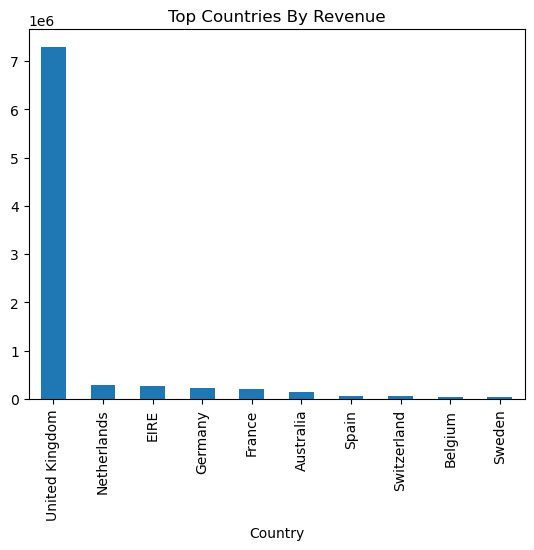

In [ ]:
country_sales.plot(kind='bar')
plt.title('Top Countries By Revenue')
plt.show()

# 💷 COUNTRY REVENUE INSIGHTS
"""
 KEY FINDINGS:
• UK makes most MONEY ($7.3M!)
• Netherlands customers spend BIG per order ($121 average!)
• Some countries have few orders but high spending

 WHAT THIS MEANS:
UK pays the bills - keep them happy! 
Dutch customers love spending - target them more!
Maybe create special deals for high-value countries?
"""

In [32]:
# Q17: How many Countries are there
df['Country'].nunique()

37

In [33]:
# Q18: Which country has the most order 
df['Country'].value_counts().head()

Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Name: count, dtype: int64

In [34]:
# Q19: Which Country Generates Higher Revenue 
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

Country
United Kingdom          7285024.644
Netherlands              285446.340
EIRE                     265262.460
Germany                  228678.400
France                   208934.310
Australia                138453.810
Spain                     61558.560
Switzerland               56443.950
Belgium                   41196.340
Sweden                    38367.830
Japan                     37416.370
Norway                    36165.440
Portugal                  33375.840
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20440.540
Denmark                   18955.340
Italy                     17483.240
Cyprus                    13502.850
Austria                   10198.680
Poland                     7334.650
Israel                     7215.840
Greece                     4760.520
Iceland                    4310.000
Canada                     3666.380
USA                        3580.390
Malta                      2725.590
Unspecified         

In [35]:
# Q20: Which Country buys the most quatnity 
df.groupby('Country')['Quantity'].sum().sort_values(ascending=False)

Country
United Kingdom          4241305
Netherlands              200361
EIRE                     140133
Germany                  119154
France                   111428
Australia                 83891
Sweden                    36078
Switzerland               30082
Spain                     27933
Japan                     26016
Belgium                   23237
Norway                    19336
Portugal                  16095
Finland                   10704
Channel Islands            9485
Denmark                    8235
Italy                      8112
Cyprus                     6340
Singapore                  5241
Austria                    4881
Israel                     4043
Poland                     3684
Canada                     2763
Iceland                    2458
USA                        2458
Unspecified                1785
Greece                     1557
United Arab Emirates        982
Malta                       970
Czech Republic              671
Lithuania                   652


In [36]:
# Q21: Average order value by country 
df.groupby('Country')['TotalPrice'].mean().sort_values(ascending=False)

Country
Netherlands             121.003111
Australia               117.234386
Japan                   116.561900
Singapore                95.852658
Sweden                   85.261844
Denmark                  49.882474
Lithuania                47.458857
Lebanon                  37.641778
EIRE                     36.709446
Brazil                   35.737500
Norway                   33.767918
Czech Republic           33.069600
Finland                  32.913985
Greece                   32.831172
Bahrain                  32.258824
Switzerland              30.659397
Israel                   29.452408
United Arab Emirates     27.974706
Channel Islands          27.363507
Austria                  25.624824
Germany                  25.338327
France                   25.094200
Spain                    24.832013
Malta                    24.335625
Canada                   24.280662
Iceland                  23.681319
Italy                    23.064960
Portugal                 22.970296
Cyprus      

SECTION D: TIME ANALYSIS

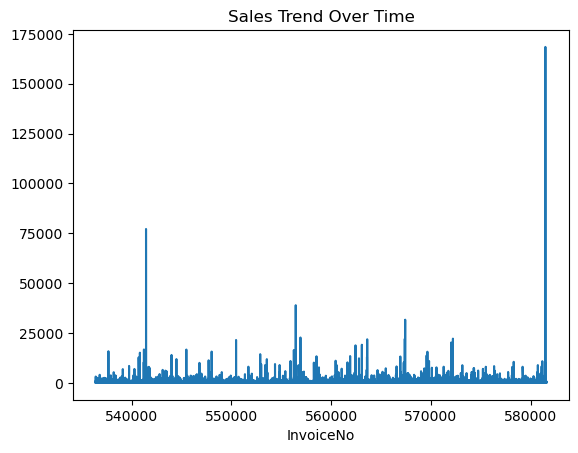

In [ ]:
daily_sales.plot()
plt.title("Sales Trend Over Time")
plt.show()

#  SALES TREND INSIGHTS
"""
 KEY FINDINGS:
• Sales go UP throughout the year
• HUGE spike at end (holidays! )
• Some weird ups and downs in between

 WHAT THIS MEANS:
Business is GROWING!  
Holiday season is CRITICAL - prepare well
Maybe investigate why some days are weirdly high/low?
"""

In [38]:
# Q23: How many unique days of data 
df['InvoiceDate'].dt.date.unique()

array([datetime.date(2010, 12, 1), datetime.date(2010, 12, 2),
       datetime.date(2010, 12, 3), datetime.date(2010, 12, 5),
       datetime.date(2010, 12, 6), datetime.date(2010, 12, 7),
       datetime.date(2010, 12, 8), datetime.date(2010, 12, 9),
       datetime.date(2010, 12, 10), datetime.date(2010, 12, 12),
       datetime.date(2010, 12, 13), datetime.date(2010, 12, 14),
       datetime.date(2010, 12, 15), datetime.date(2010, 12, 16),
       datetime.date(2010, 12, 17), datetime.date(2010, 12, 19),
       datetime.date(2010, 12, 20), datetime.date(2010, 12, 21),
       datetime.date(2010, 12, 22), datetime.date(2010, 12, 23),
       datetime.date(2011, 1, 4), datetime.date(2011, 1, 5),
       datetime.date(2011, 1, 6), datetime.date(2011, 1, 7),
       datetime.date(2011, 1, 9), datetime.date(2011, 1, 10),
       datetime.date(2011, 1, 11), datetime.date(2011, 1, 12),
       datetime.date(2011, 1, 13), datetime.date(2011, 1, 14),
       datetime.date(2011, 1, 16), datetime.date

In [ ]:
df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum().sort_values(ascending=False).head()

In [ ]:
#  BEST SALES DAYS INSIGHTS
"""
 KEY FINDINGS:
• December 9, 2011 = BEST DAY EVER ($184K!)
• Top 5 days are ALL near Christmas
• September 20 was surprisingly good ($103K)

 WHAT THIS MEANS:
Christmas shopping is REAL!
Stock up BIG TIME in November/December
Maybe that September day had a special promotion?
"""

InvoiceDate
2011-12-09    184329.66
2011-09-20    103377.68
2011-01-18     87559.21
2011-10-05     73975.57
2011-09-15     71926.69
Name: TotalPrice, dtype: float64

In [40]:
# Q20: Which month has lowest sales 
df.groupby(df['InvoiceDate'].dt.month)['Quantity'].sum().sort_values(ascending=False)

InvoiceDate
11    665923
12    597825
10    591543
9     543652
8     397373
5     372864
7     367360
6     363014
1     348473
3     347582
4     291366
2     265027
Name: Quantity, dtype: int64

In [ ]:
df.groupby(df['InvoiceDate'].dt.month)['Quantity'].sum().sort_values(ascending=False)

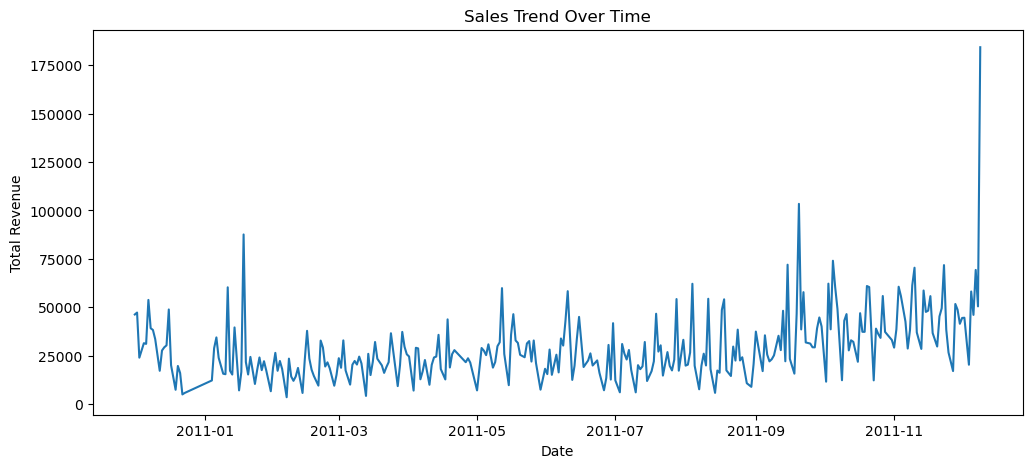

In [ ]:
#  MONTHLY QUANTITY INSIGHTS
"""
 KEY FINDINGS:
• November = BUSIEST month (665k items sold!)
• December = #2 (597k items)
• February = SLOWEST month (only 265k items)

 WHAT THIS MEANS:
Holiday rush is REAL!  People buy A LOT
February is dead month - maybe run Valentine's sales?
Plan staffing: need more people in Nov/Dec!
"""

In [ ]:
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum()
plt.figure(figsize=(12,5))
daily_sales.plot()

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Revenue")

plt.show()

#  DETAILED SALES TREND INSIGHTS
"""
 KEY FINDINGS:
• Clear UPWARD trend throughout 2011
• Massive spike at year-end (holidays!)
• Some random big spikes during year

 WHAT THIS MEANS:
Business is HEALTHY and GROWING! 
Year-end holidays make or break the year
Those random spikes? Maybe big promotions or events?
"""